In [1]:
#STEP 0: ENVIRONMENT SETUP & DATA FETCHING OPTIONS
# ---------------------------------------------------------------------
# Uncomment the method that matches how you want to bring in your data:
#
# --- METHOD A: Drag and Drop CSV directly into Colab's file panel ---
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])
#
# --- METHOD B: Fetching directly from Google Drive ---
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/your_folder/fraud_data.csv')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, roc_auc_score, classification_report, roc_curve

# --- SIMULATING AN UNBALANCED FRAUD DATASET ---
# Generating 5,000 transactions where only ~1.5% are fraudulent instances
np.random.seed(42)
n_samples = 5000
n_fraud = 75

# Valid normal transactional features
normal_features = np.random.normal(loc=0.0, scale=1.0, size=(n_samples - n_fraud, 5))
# Fraudulent patterns showing signature distinct variance clusters
fraud_features = np.random.normal(loc=2.5, scale=1.5, size=(n_fraud, 5))

X_raw = np.vstack([normal_features, fraud_features])
y_raw = np.array([0] * (n_samples - n_fraud) + [1] * n_fraud)

# Constructing data matrix
df_raw = pd.DataFrame(X_raw, columns=[f'Transaction_Feature_{i+1}' for i in range(5)])
df_raw['Is_Fraud'] = y_raw

print("⚠️ INITIAL IMBLANCE CHECK:")
print(df_raw['Is_Fraud'].value_counts(normalize=True))
print(f"Total Transactions: {len(df_raw)} | Legitimate: {df_raw['Is_Fraud'].value_counts()[0]} | Fraud: {df_raw['Is_Fraud'].value_counts()[1]}")
print("-" * 75)

⚠️ INITIAL IMBLANCE CHECK:
Is_Fraud
0    0.985
1    0.015
Name: proportion, dtype: float64
Total Transactions: 5000 | Legitimate: 4925 | Fraud: 75
---------------------------------------------------------------------------


In [2]:
# =====================================================================
# MODULE 1: STRATIFIED PARTITIONING (AVOIDING DATA LEAKAGE)
# =====================================================================
def module_1_prepare_splits(df: pd.DataFrame, target_col: str):
    """
    Splits data BEFORE rebalancing. Uses stratification to preserve minority
    proportions evenly across splits.
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Crucial step: split first to isolate test metrics cleanly
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # Scale feature dimensions to help linear model optimization vectors converge
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("[PIPELINE] Data stratified split complete. Test validation isolation preserved.")
    return X_train_scaled, X_test_scaled, y_train, y_test

In [3]:
# =====================================================================
# MODULE 2: MINORITY INTERPOLATION LAYER (SMOTE SYNTHESIS)
# =====================================================================
def module_2_apply_smote(X_train, y_train):
    """
    Manually implements a vector interpolation process mimicking SMOTE logic:
    x_new = x_i + lambda * (x_nn - x_i) where lambda ~ Uniform(0,1).
    Fills space vectors inside the training subset only.
    """
    print("[BALANCING] Initializing SMOTE minority interpolation engine...")

    # Extract minority indices
    minority_idx = np.where(y_train == 1)[0]
    minority_samples = X_train[minority_idx]

    num_synthetic_needed = np.where(y_train == 0)[0].shape[0] - minority_samples.shape[0]
    synthetic_features = []

    for _ in range(num_synthetic_needed):
        # Pick a random sample from minority population
        idx = np.random.choice(minority_idx)
        x_i = X_train[idx]

        # Find neighbors within the minority class to calculate local distances
        other_minority_samples = minority_samples[~np.all(minority_samples == x_i, axis=1)]
        distances = np.linalg.norm(other_minority_samples - x_i, axis=1)

        # Identify nearest vector point coordinate (k=1 variant lookup)
        x_nn = other_minority_samples[np.argmin(distances)]

        # Linear interpolation weight drawing
        lam = np.random.uniform(0, 1)
        x_new = x_i + lam * (x_nn - x_i)
        synthetic_features.append(x_new)

    X_synthetic = np.vstack(synthetic_features)
    y_synthetic = np.ones(num_synthetic_needed)

    # Balance structural dataset safely
    X_train_balanced = np.vstack([X_train, X_synthetic])
    y_train_balanced = np.concatenate([y_train, y_synthetic])

    print(f"[BALANCING] Resampling Complete. Training Balance Count: {pd.Series(y_train_balanced).value_counts().to_dict()}")
    return X_train_balanced, y_train_balanced

In [4]:
# =====================================================================
# MODULE 3: ESTIMATION & PIPELINE MODELING
# =====================================================================
def module_3_train_estimators(X_train, y_train):
    """
    Fits classification learners on balanced metrics.
    """
    print("\n[ESTIMATION] Training Target Classifiers...")

    # Model A: Linear Baseline (Logistic Regression)
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_train, y_train)
    print(" -> Logistic Regression Model fitted successfully.")

    # Model B: Ensemble Estimator (Random Forest)
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
    rf_model.fit(X_train, y_train)
    print(" -> Random Forest Classifier Model fitted successfully.")

    return lr_model, rf_model

[PIPELINE] Data stratified split complete. Test validation isolation preserved.
[BALANCING] Initializing SMOTE minority interpolation engine...
[BALANCING] Resampling Complete. Training Balance Count: {0.0: 3940, 1.0: 3940}

[ESTIMATION] Training Target Classifiers...
 -> Logistic Regression Model fitted successfully.
 -> Random Forest Classifier Model fitted successfully.

[EVALUATION] Computing Rigorous Performance Audit Matrix...

================📊 Logistic Regression Baseline 📊================
Precision Score (When we flag fraud, are we right?)  : 0.7143
Recall Score (Did we catch all the active fraud?)   : 1.0000
ROC-AUC Capability (Distribution Separation Boundary): 1.0000

Full Classification Performance Profile:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00       985
  Fraudulent       0.71      1.00      0.83        15

    accuracy                           0.99      1000
   macro avg       0.86      1.00      0.92      100

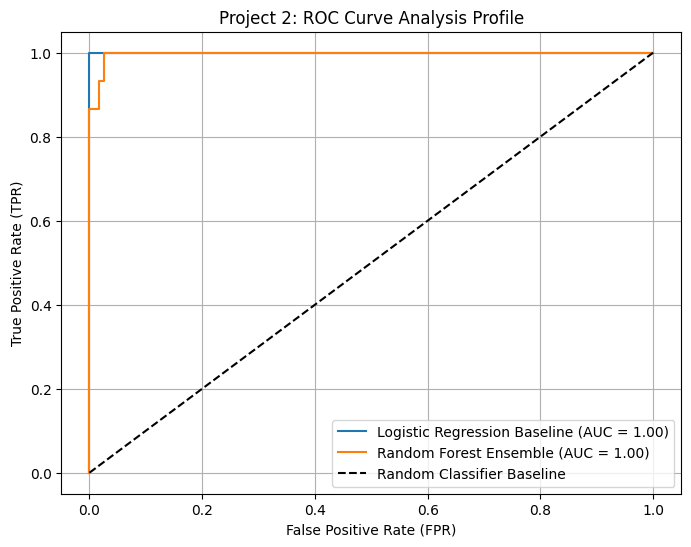

In [5]:
# =====================================================================
# MODULE 4: ALGORIHTMIC PRECISION EVALUATION
# =====================================================================
def module_4_evaluate_system(lr_model, rf_model, X_test, y_test):
    """
    Discards accuracy metrics completely to calculate exact corporate risks:
    Precision, Recall, and Receiver Operating Characteristic AUC vectors.
    """
    print("\n[EVALUATION] Computing Rigorous Performance Audit Matrix...")

    models = {'Logistic Regression Baseline': lr_model, 'Random Forest Ensemble': rf_model}

    plt.figure(figsize=(8, 6))

    for name, model in models.items():
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

        precision = precision_score(y_test, preds)
        recall = recall_score(y_test, preds)
        auc_score = roc_auc_score(y_test, probs)

        print(f"\n================📊 {name} 📊================")
        print(f"Precision Score (When we flag fraud, are we right?)  : {precision:.4f}")
        print(f"Recall Score (Did we catch all the active fraud?)   : {recall:.4f}")
        print(f"ROC-AUC Capability (Distribution Separation Boundary): {auc_score:.4f}")
        print("\nFull Classification Performance Profile:")
        print(classification_report(y_test, preds, target_names=['Legitimate', 'Fraudulent']))

        # Plotting the separation curves
        fpr, tpr, _ = roc_curve(y_test, probs)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier Baseline')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Project 2: ROC Curve Analysis Profile')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# ---------------------------------------------------------------------
# PIPELINE EXECUTION LAYER
# ---------------------------------------------------------------------
# Running pipeline using atomic functional steps
X_tr, X_te, y_tr, y_te = module_1_prepare_splits(df_raw, target_col='Is_Fraud')
X_tr_bal, y_tr_bal    = module_2_apply_smote(X_tr, y_tr)
lr_est, rf_est         = module_3_train_estimators(X_tr_bal, y_tr_bal)

# Run strict diagnostic checks against our validation pipeline test sets
module_4_evaluate_system(lr_est, rf_est, X_te, y_te)